In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style
sns.set_theme(style="whitegrid")

# Load the data
base_linux = pd.read_csv('real_first/base_linux.csv')
base_unikernel = pd.read_csv('real_first/base_unikernel.csv')
optimized_linux = pd.read_csv('real_first/optimized_linux.csv')
optimized_unikernel = pd.read_csv('real_first/optimized_unikernel.csv')

# Add source column to identify each dataset
base_linux['source'] = 'Base Linux'
base_unikernel['source'] = 'Base Unikernel'
optimized_linux['source'] = 'Optimized Linux'
optimized_unikernel['source'] = 'Optimized Unikernel'

# Combine all data
all_data = pd.concat([base_linux, base_unikernel, optimized_linux, optimized_unikernel], ignore_index=True)

print("Unique benchmarks:", all_data['benchmark'].unique())
print("\nData shape:", all_data.shape)
print("\nSamples per benchmark and source:")
print(all_data.groupby(['benchmark', 'source']).size().unstack(fill_value=0))

Unique benchmarks: ['crc32' 'cubic' 'dijkstra' 'fdct' 'fir' 'matmult-float' 'matmult-int'
 'nettle-sha256' 'rijndael']

Data shape: (1800, 18)

Samples per benchmark and source:
source         Base Linux  Base Unikernel  Optimized Linux  \
benchmark                                                    
crc32                  50              50               50   
cubic                  50              50               50   
dijkstra               50              50               50   
fdct                   50              50               50   
fir                    50              50               50   
matmult-float          50              50               50   
matmult-int            50              50               50   
nettle-sha256          50              50               50   
rijndael               50              50               50   

source         Optimized Unikernel  
benchmark                           
crc32                           50  
cubic                       

In [29]:
# Comprehensive runtime characteristics summary for all benchmarks
print("=" * 100)
print("BENCHMARK RUNTIME CHARACTERISTICS SUMMARY")
print("=" * 100)

for benchmark in all_benchmarks:
    print(f"\n{'='*100}")
    print(f"BENCHMARK: {benchmark.upper()}")
    print(f"{'='*100}")
    
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    
    # Create summary statistics for each configuration
    summary_stats = []
    
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]
        
        if len(source_data) > 0:
            stats_dict = {
                'Configuration': source,
                'Samples': len(source_data),
                
                # Energy metrics
                'Energy Mean (J)': source_data['total_joules'].mean(),
                'Energy Std (J)': source_data['total_joules'].std(),
                'Energy CV (%)': (source_data['total_joules'].std() / source_data['total_joules'].mean() * 100),
                'Energy Min (J)': source_data['total_joules'].min(),
                'Energy Max (J)': source_data['total_joules'].max(),
                'Energy Range (J)': source_data['total_joules'].max() - source_data['total_joules'].min(),
                
                # CPU cycles metrics
                'Cycles Mean': source_data['cpu_cycles'].mean(),
                'Cycles Std': source_data['cpu_cycles'].std(),
                'Cycles CV (%)': (source_data['cpu_cycles'].std() / source_data['cpu_cycles'].mean() * 100),
                'Cycles Min': source_data['cpu_cycles'].min(),
                'Cycles Max': source_data['cpu_cycles'].max(),
                
                # Runtime metrics (if available)
                'Runtime Mean (ms)': source_data['runtime_ms'].mean() if 'runtime_ms' in source_data.columns else np.nan,
                'Runtime Std (ms)': source_data['runtime_ms'].std() if 'runtime_ms' in source_data.columns else np.nan,
                'Runtime CV (%)': (source_data['runtime_ms'].std() / source_data['runtime_ms'].mean() * 100) if 'runtime_ms' in source_data.columns else np.nan,
            }
            summary_stats.append(stats_dict)
    
    # Create DataFrame
    summary_df = pd.DataFrame(summary_stats)
    summary_df = summary_df.set_index('Configuration')
    
    # Display energy metrics
    print("\nENERGY CONSUMPTION:")
    print("-" * 100)
    energy_cols = ['Samples', 'Energy Mean (J)', 'Energy Std (J)', 'Energy CV (%)', 'Energy Min (J)', 'Energy Max (J)', 'Energy Range (J)']
    pd.set_option('display.float_format', lambda x: f'{x:.6g}')
    display(summary_df[energy_cols])
    
    # Display CPU cycles metrics
    print("\nCPU CYCLES:")
    print("-" * 100)
    cycles_cols = ['Cycles Mean', 'Cycles Std', 'Cycles CV (%)', 'Cycles Min', 'Cycles Max']
    pd.set_option('display.float_format', lambda x: f'{x:.8g}')
    display(summary_df[cycles_cols])
    
    # Display runtime metrics if available
    if 'runtime_ms' in benchmark_data.columns:
        print("\nRUNTIME:")
        print("-" * 100)
        runtime_cols = ['Runtime Mean (ms)', 'Runtime Std (ms)', 'Runtime CV (%)']
        display(summary_df[runtime_cols])
    
    # Highlight high variability
    high_var_configs = summary_df[summary_df['Energy CV (%)'] > 5.0]
    if len(high_var_configs) > 0:
        print("\n⚠️  HIGH VARIABILITY DETECTED (CV > 5%):")
        print("-" * 100)
        print(high_var_configs[['Energy CV (%)', 'Cycles CV (%)']].to_string())

print(f"\n{'='*100}")
print("SUMMARY COMPLETE")
print(f"{'='*100}")

BENCHMARK RUNTIME CHARACTERISTICS SUMMARY

BENCHMARK: CRC32

ENERGY CONSUMPTION:
----------------------------------------------------------------------------------------------------


,Samples,Energy Mean (J),Energy Std (J),Energy CV (%),Energy Min (J),Energy Max (J),Energy Range (J)
Configuration,,,,,,,
Base Linux,50,303.66,11.2287,3.69777,294.776,360.861,66.0849
Optimized Linux,50,280.026,0.597757,0.213465,277.422,280.631,3.20935
Base Unikernel,50,264.593,0.918055,0.346969,262.009,265.505,3.49606
Optimized Unikernel,50,265.019,0.238223,0.0898887,264.254,265.372,1.11816



CPU CYCLES:
----------------------------------------------------------------------------------------------------


,Cycles Mean,Cycles Std,Cycles CV (%),Cycles Min,Cycles Max
Configuration,,,,,
Base Linux,5.2281217e+10,1.1980942e+08,0.22916341,52251638113,52951279928
Optimized Linux,5.7158145e+10,936795,0.0016389528,57153670904,57158966904
Base Unikernel,5.7142044e+10,292047.44,0.00051109029,57141497220,57142874324
Optimized Unikernel,5.7139758e+10,445921.5,0.00078040494,57139277700,57140468484



BENCHMARK: CUBIC

ENERGY CONSUMPTION:
----------------------------------------------------------------------------------------------------


...


BENCHMARK: RIJNDAEL

ENERGY CONSUMPTION:
----------------------------------------------------------------------------------------------------


,Samples,Energy Mean (J),Energy Std (J),Energy CV (%),Energy Min (J),Energy Max (J),Energy Range (J)
Configuration,,,,,,,
Base Linux,50,343.766,0.73098,0.212639,343.335,348.677,5.34212
Optimized Linux,50,312.895,0.22635,0.0723406,312.501,313.59,1.08867
Base Unikernel,50,300.462,0.149287,0.0496859,300.188,300.788,0.599549
Optimized Unikernel,50,300.542,0.145971,0.0485692,300.29,300.831,0.541519



CPU CYCLES:
----------------------------------------------------------------------------------------------------


,Cycles Mean,Cycles Std,Cycles CV (%),Cycles Min,Cycles Max
Configuration,,,,,
Base Linux,4.7385265e+10,13812660,0.029149694,47359819951,47434777289
Optimized Linux,5.1732542e+10,483628.07,0.00093486238,51731298076,51733195340
Base Unikernel,5.1659392e+10,298268.46,0.0005773751,51658978820,51659964895
Optimized Unikernel,5.1657293e+10,224337.96,0.0004342813,51656957948,51657763392



SUMMARY COMPLETE


# Benchmark Runtime Characteristics Analysis

Analysis of execution time, energy consumption, and variability across all benchmarks and configurations.

In [30]:
# Define variables for plotting
all_benchmarks = all_data['benchmark'].unique().tolist()
hue_order = ['Base Linux', 'Optimized Linux', 'Base Unikernel', 'Optimized Unikernel']
palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

# Group benchmarks for multi-panel plots
benchmark_groups = [all_benchmarks]  # Single group with all benchmarks

print(f"All benchmarks: {all_benchmarks}")
print(f"Configuration order: {hue_order}")
print(f"Color palette: {palette}")

All benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
Configuration order: ['Base Linux', 'Optimized Linux', 'Base Unikernel', 'Optimized Unikernel']
Color palette: ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']


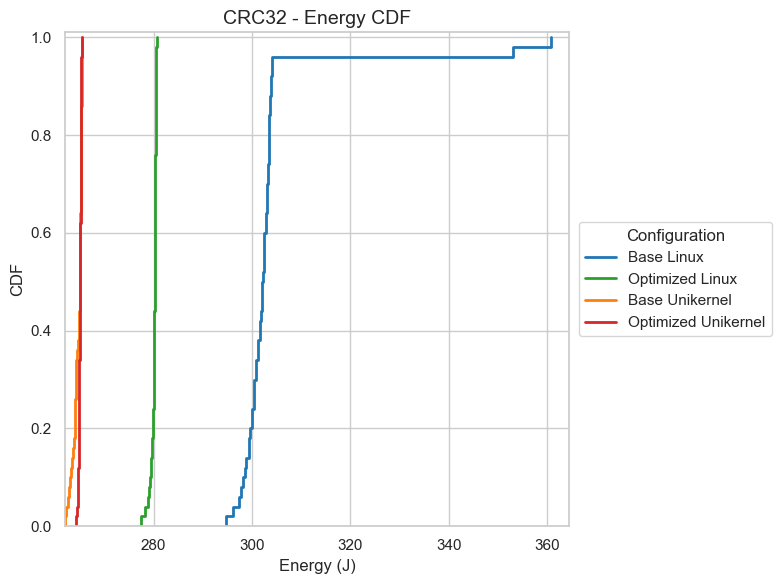

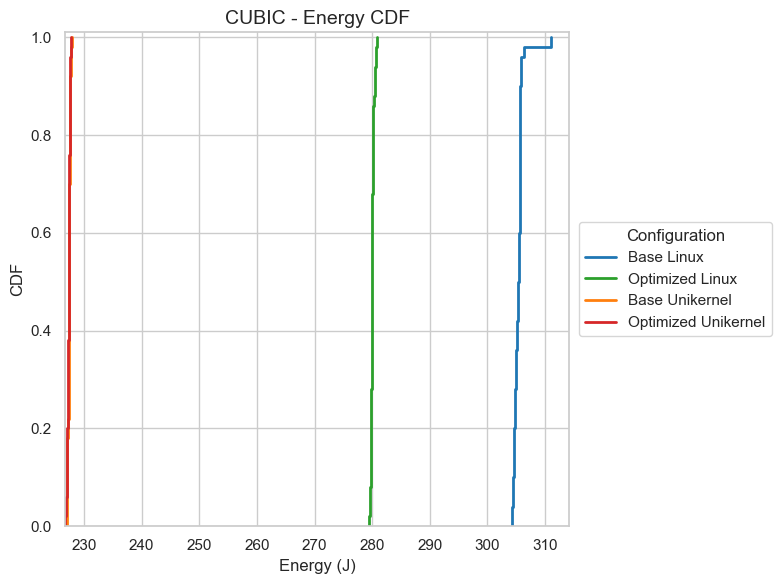

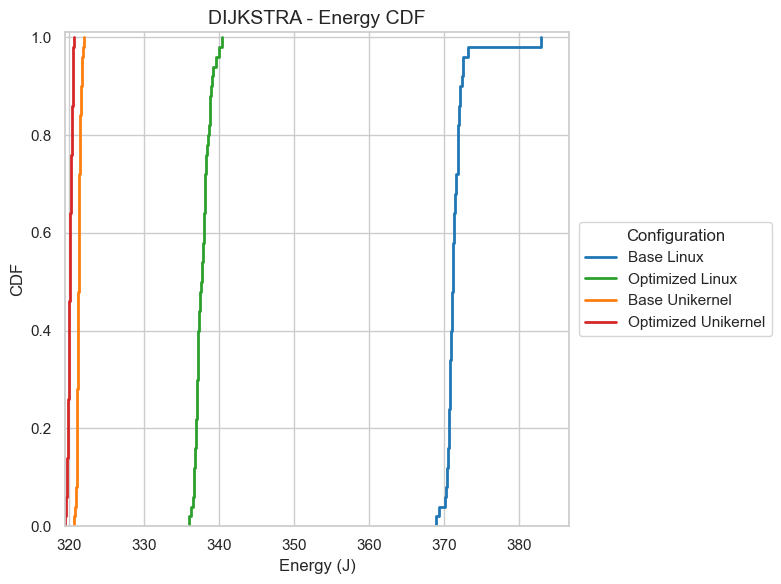

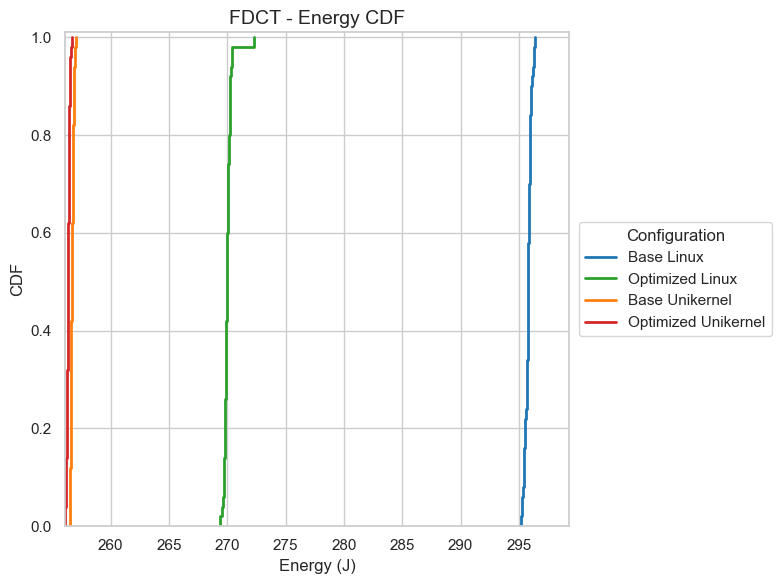

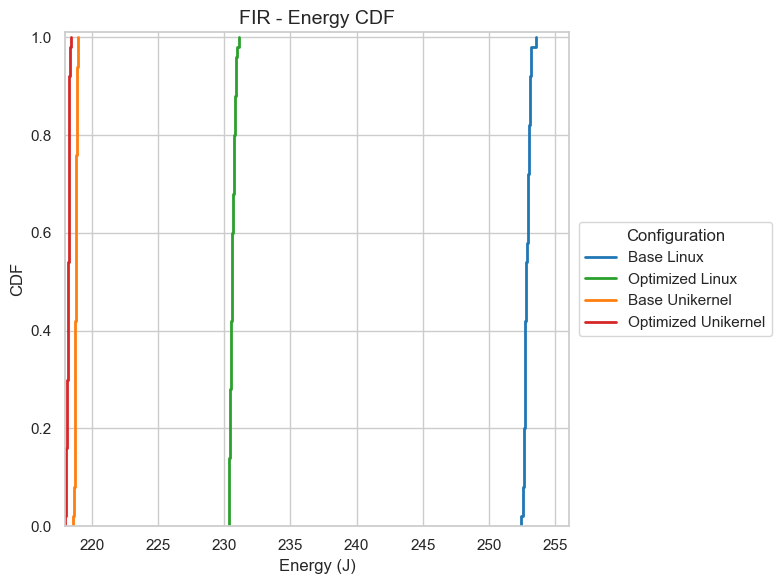

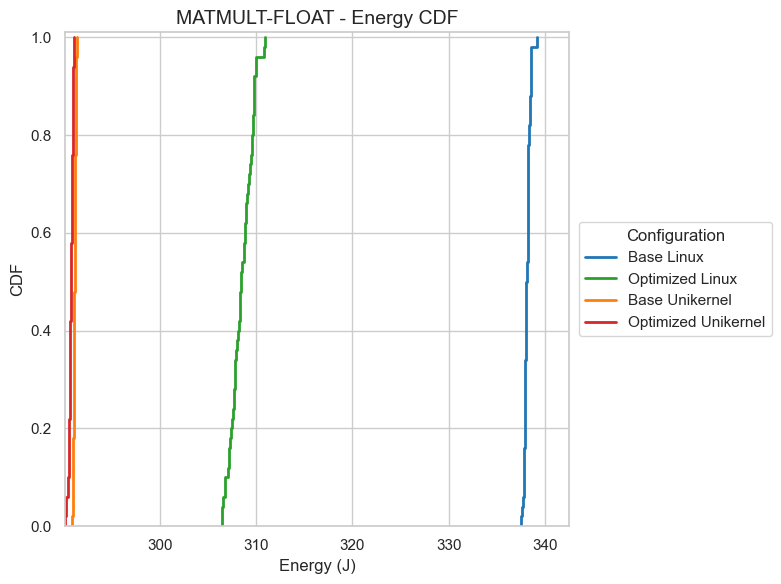

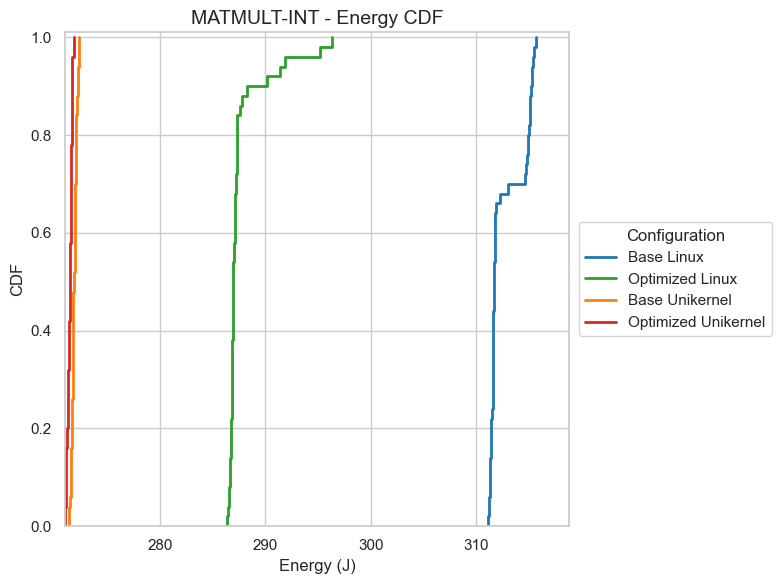

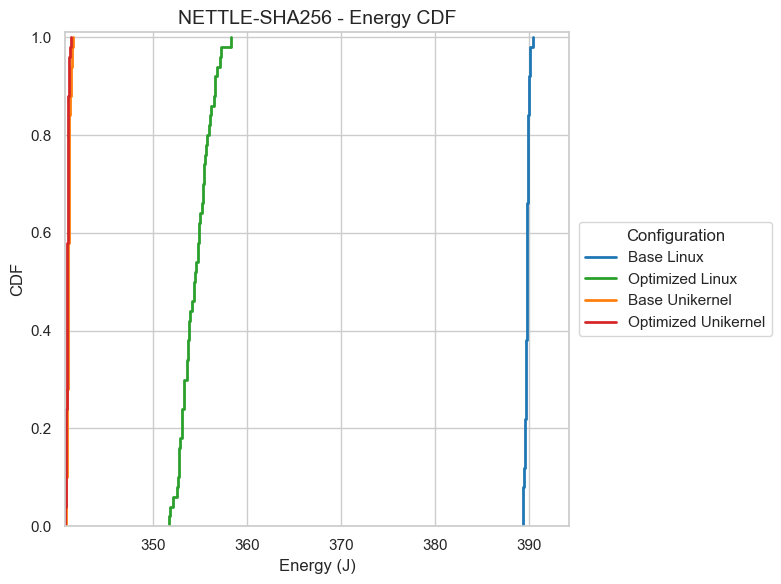

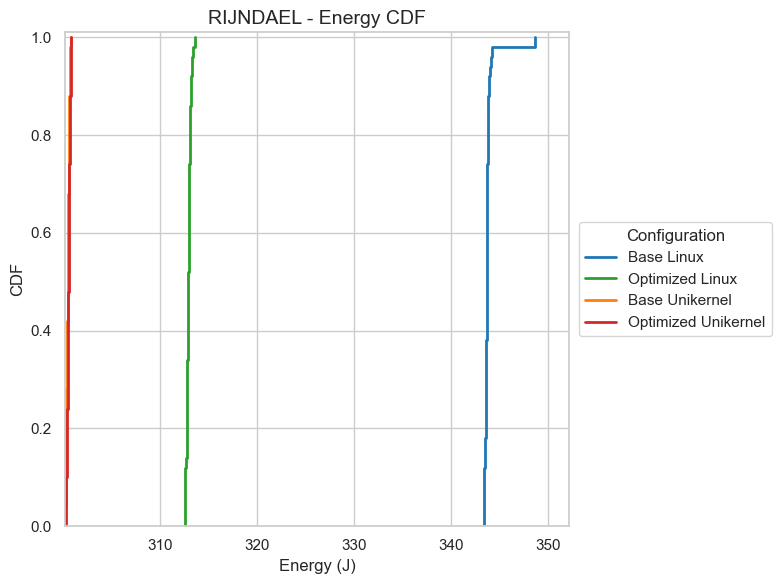

In [31]:
filtered_benchmarks = all_data['benchmark'].unique()
for benchmark in filtered_benchmarks:
    fig, ax = plt.subplots(figsize=(8, 6))
    benchmark_data = all_data[all_data['benchmark'] == benchmark]

    for source, color in zip(hue_order, palette):
        source_data = benchmark_data[benchmark_data['source'] == source]
        if not source_data.empty:
            
            sns.ecdfplot(
                data=source_data,
                x='total_joules',
                color=color,
                linewidth=2,
                ax=ax,
                label=source
            )
        else:
            ax.plot([], [], color=color, label=source)

    ax.set_xlabel('Energy (J)', fontsize=12)
    ax.set_ylabel('CDF', fontsize=12)
    ax.set_title(f'{benchmark.upper()} - Energy CDF', fontsize=14)

    # Ensure full CDF is visible
    ax.set_ylim(0.0, 1.01)
    xmin = benchmark_data['total_joules'].min()
    xmax = benchmark_data['total_joules'].max()
    ax.set_xlim(xmin, xmax * 1.01)

    # Legend outside
    ax.legend(title='Configuration',
              loc='center left',
              bbox_to_anchor=(1.02, 0.5),
              borderaxespad=0)

    plt.tight_layout()
    plt.savefig(f'energy_cdf_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()



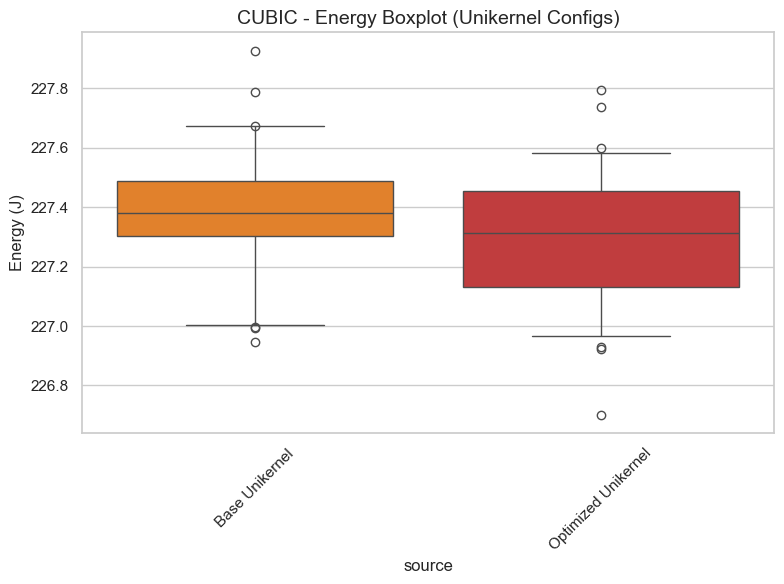

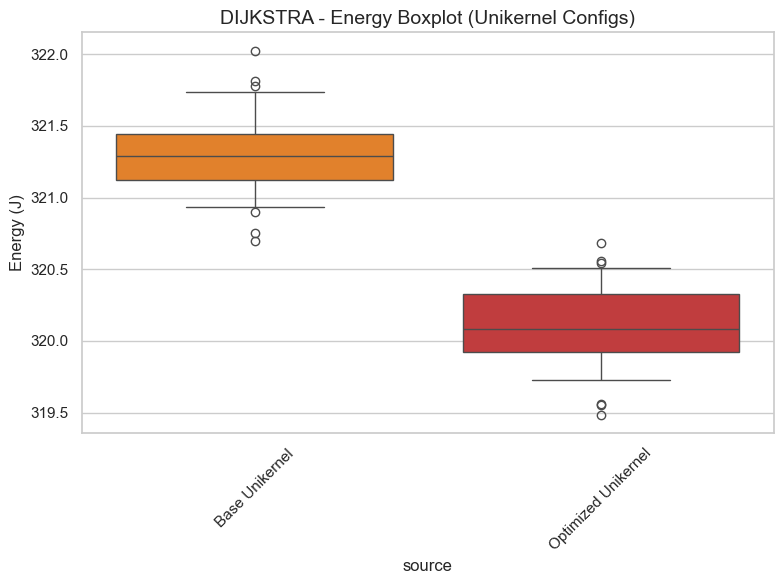

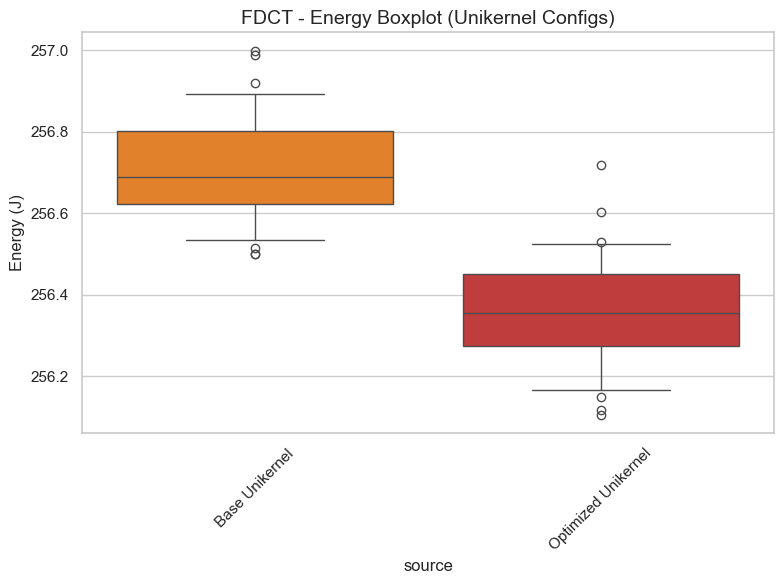

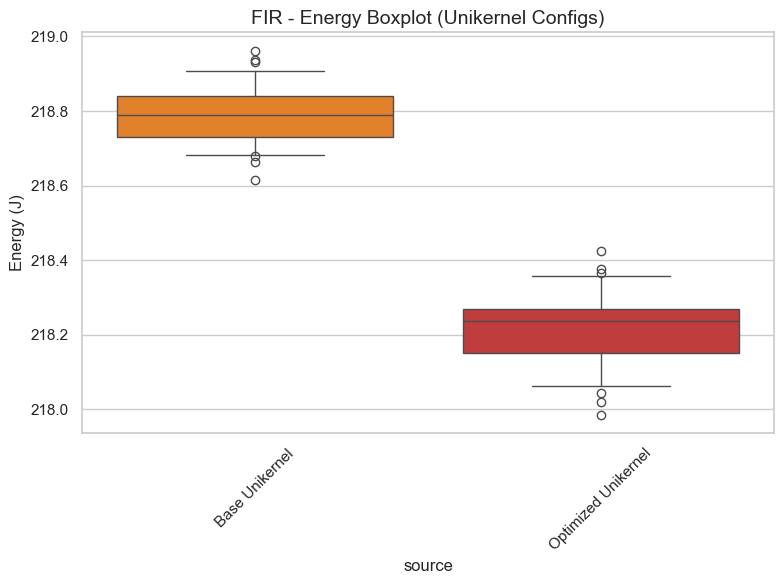

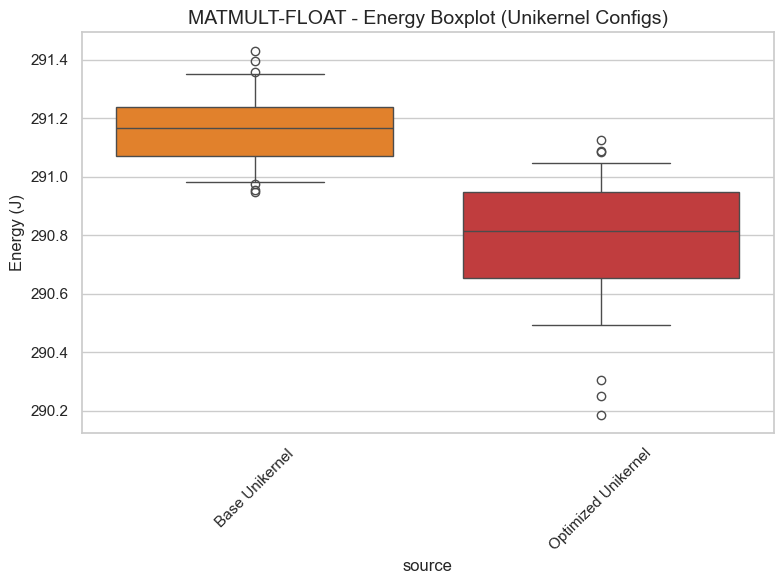

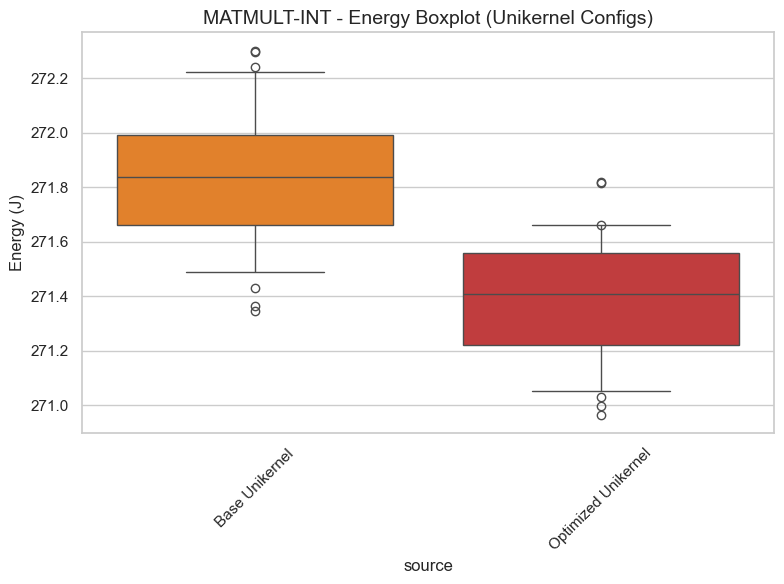

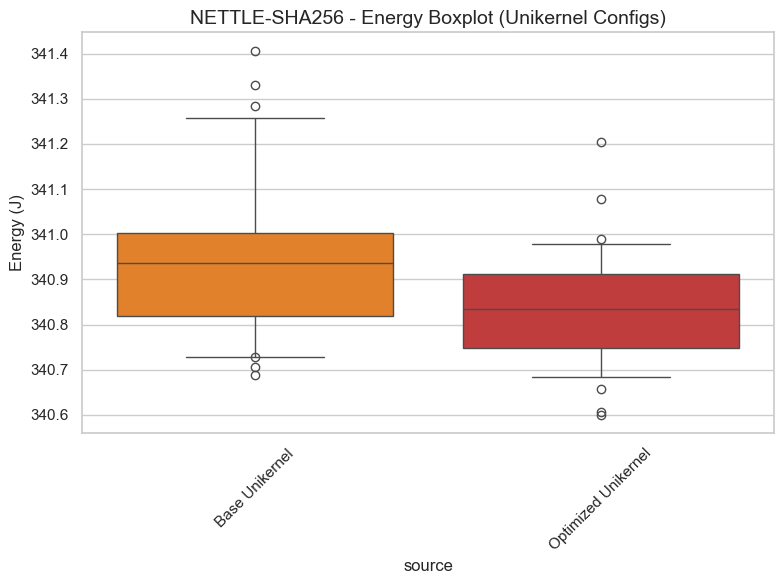

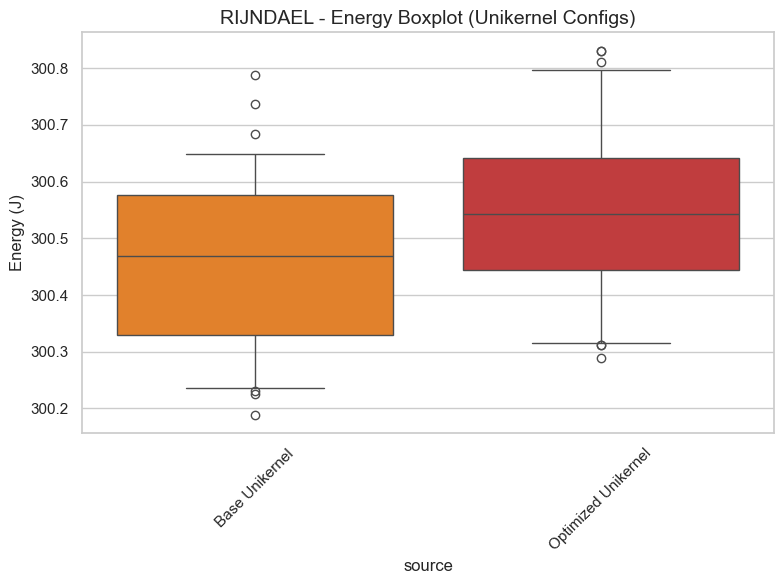

In [32]:
# Create boxplot for each benchmark individually (one plot per benchmark, unikernel configs only)
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for unikernel configurations only
unikernel_hue_order = ['Base Unikernel', 'Optimized Unikernel']
unikernel_palette = ['#ff7f0e', '#d62728']  # Orange and red

# Optionally exclude 'crc32' for consistency with other plots
filtered_benchmarks = [b for b in all_benchmarks if b != 'crc32']

for benchmark in filtered_benchmarks:
    fig, ax = plt.subplots(figsize=(8, 6))
    benchmark_data = all_data[(all_data['benchmark'] == benchmark) & 
                               (all_data['source'].isin(unikernel_hue_order))]
    
    sns.boxplot(
        data=benchmark_data,
        x='source',
        y='total_joules',
        hue='source',
        hue_order=unikernel_hue_order,
        palette=unikernel_palette,
        ax=ax,
        order=unikernel_hue_order,
        whis=(5, 95)
    )
    
    # ax.set_xlabel('Configuration', fontsize=12)
    ax.set_ylabel('Energy (J)', fontsize=12)
    ax.set_title(f'{benchmark.upper()} - Energy Boxplot (Unikernel Configs)', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    # ax.legend(title='Configuration', loc='upper right')
    plt.tight_layout()
    plt.show()


In [33]:
# Calculate standard deviation for all benchmarks and sources
std_data = []
for benchmark in all_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]['total_joules']
        row[source] = source_data.std()
    std_data.append(row)

# Create DataFrame and display
std_df = pd.DataFrame(std_data)
std_df = std_df.set_index('Benchmark')

# Format to 8 significant digits
print("Standard Deviation of Energy (J) by Benchmark and Configuration:")
print("=" * 80)
pd.set_option('display.float_format', lambda x: f'{x:.8g}')
display(std_df)

Standard Deviation of Energy (J) by Benchmark and Configuration:


,Base Linux,Optimized Linux,Base Unikernel,Optimized Unikernel
Benchmark,,,,
crc32,11.228669,0.59775697,0.91805514,0.23822254
cubic,0.95965517,0.26943242,0.21201616,0.22422755
dijkstra,1.8192765,0.95779565,0.26784845,0.28063448
fdct,0.26164477,0.39211998,0.1248397,0.12610911
fir,0.21669372,0.17770687,0.076301832,0.096227049
matmult-float,0.29570502,1.1316299,0.12051784,0.2127476
matmult-int,1.6614867,1.9988813,0.24503623,0.21993435
nettle-sha256,0.20936755,1.5433952,0.16696143,0.12104856
rijndael,0.73098035,0.22635022,0.14928711,0.14597119


Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (%), excluding crc32:


,Base Linux,Optimized Linux,Base Unikernel,Optimized Unikernel
Benchmark,,,,
cubic,0.31428116,0.096225857,0.093245997,0.098644309
dijkstra,0.48980627,0.28358358,0.083363865,0.087668114
fdct,0.088456789,0.1452164,0.048631554,0.04919229
fir,0.085703417,0.077059799,0.034874619,0.044097426
matmult-float,0.087460092,0.36683119,0.041392072,0.073164036
matmult-int,0.53133356,0.69509479,0.090145778,0.081040793
nettle-sha256,0.05371597,0.43542589,0.048969955,0.035515702
rijndael,0.21263882,0.072340596,0.049685917,0.048569237


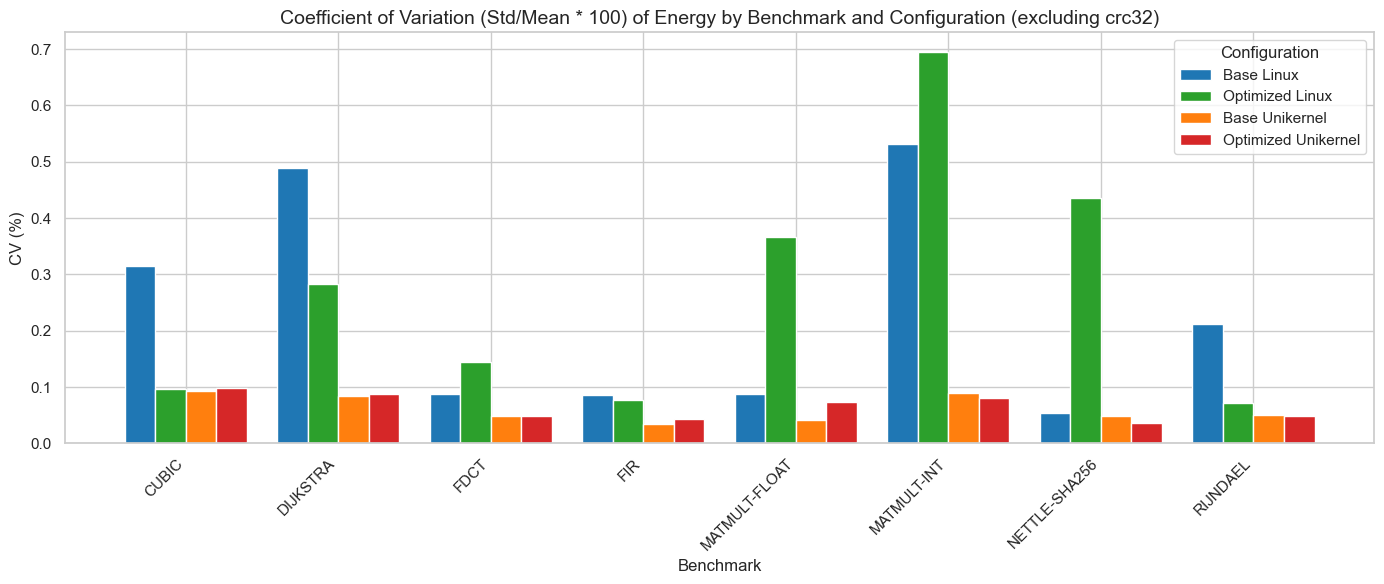

In [34]:
# Calculate coefficient of variation (CV = std/mean * 100) for all benchmarks and sources, drop crc32
filtered_benchmarks = [b for b in all_benchmarks if b != 'crc32']
cv_data = []
for benchmark in filtered_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]['total_joules']
        mean = source_data.mean()
        std = source_data.std()
        cv = (std / mean * 100) if mean != 0 else np.nan
        row[source] = cv
    cv_data.append(row)

# Create DataFrame and display
cv_df = pd.DataFrame(cv_data)
cv_df = cv_df.set_index('Benchmark')

print("Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (%), excluding crc32:")
print("=" * 80)
pd.set_option('display.float_format', lambda x: f'{x:.8g}')
display(cv_df)

# Barplot: Coefficient of Variation (CV) for Energy by Benchmark and Configuration, excluding crc32
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for plotting
cv_melted = cv_df.reset_index().melt(id_vars='Benchmark', var_name='Configuration', value_name='CV')

# Set up bar positions
x = np.arange(len(cv_df.index))
width = 0.2  # Width of each bar
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

# Plot bars for each configuration
for i, (source, color) in enumerate(zip(hue_order, palette)):
    config_data = cv_melted[cv_melted['Configuration'] == source]
    # Ensure data is in the same order as cv_df.index
    cvs = [config_data[config_data['Benchmark'] == b]['CV'].values[0] if not config_data[config_data['Benchmark'] == b].empty else np.nan for b in cv_df.index]
    ax.bar(x + offsets[i], cvs, width, label=source, color=color)

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('CV (%)', fontsize=12)
ax.set_title('Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (excluding crc32)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in cv_df.index], rotation=45, ha='right')
ax.legend(title='Configuration', loc='upper right')

plt.tight_layout()
plt.show()

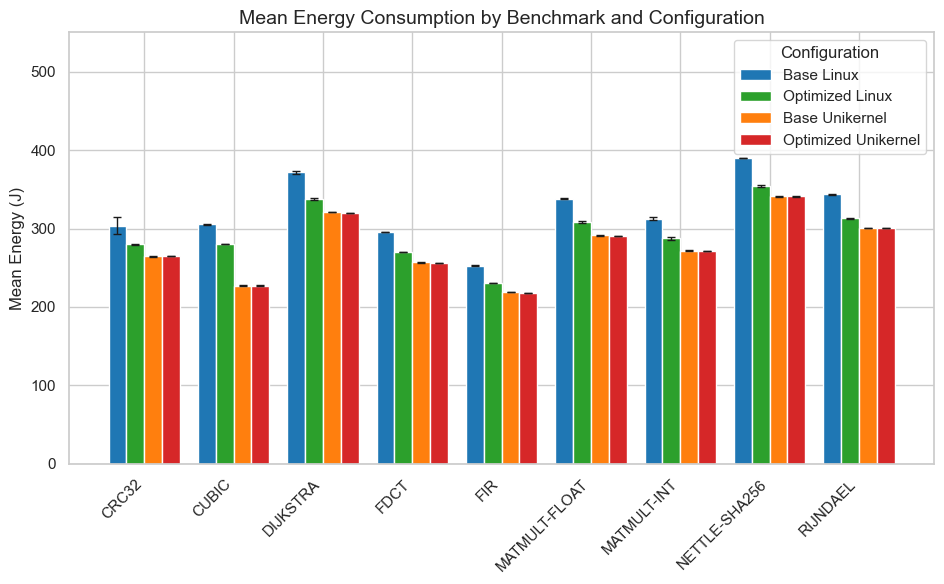

In [35]:
# Barplot: Mean Energy Consumption with Standard Deviation Error Bars by Benchmark and Configuration, excluding crc32
import matplotlib.pyplot as plt
import numpy as np

# Prepare data: exclude 'crc32'
filtered_benchmarks = [b for b in all_benchmarks if b != None]
energy_stats = all_data[all_data['benchmark'].isin(filtered_benchmarks)] \
    .groupby(['benchmark', 'source'])['total_joules'] \
    .agg(['mean', 'std']).reset_index()

# Set up bar positions
x = np.arange(len(filtered_benchmarks))
width = 0.2  # Width of each bar
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each configuration
for i, (source, color) in enumerate(zip(hue_order, palette)):
    source_data = energy_stats[energy_stats['source'] == source]
    # Ensure data is in the same order as filtered_benchmarks
    means = [source_data[source_data['benchmark'] == b]['mean'].values[0] if not source_data[source_data['benchmark'] == b].empty else np.nan for b in filtered_benchmarks]
    stds = [source_data[source_data['benchmark'] == b]['std'].values[0] if not source_data[source_data['benchmark'] == b].empty else np.nan for b in filtered_benchmarks]
    ax.bar(x + offsets[i], means, width, label=source, color=color, yerr=stds, capsize=3, error_kw={'linewidth': 1})

ax.set_ylabel('Mean Energy (J)', fontsize=12)
ax.set_title('Mean Energy Consumption by Benchmark and Configuration', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in filtered_benchmarks], rotation=45, ha='right')
ax.legend(title='Configuration', loc='upper right')
ax.set_ylim(ymax=550)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

In [36]:
# Calculate percent difference in mean energy for each configuration vs Base Linux
mean_energy = all_data.groupby(['benchmark', 'source'])['total_joules'].mean().unstack()
percent_diff = pd.DataFrame(index=mean_energy.index)

for source in hue_order:
    if source != 'Base Linux' and source in mean_energy.columns:
        percent_diff[source] = ((mean_energy[source] - mean_energy['Base Linux']) / mean_energy['Base Linux']) * 100

# Only keep columns that were actually calculated
percent_diff = percent_diff[[col for col in hue_order if col != 'Base Linux' and col in percent_diff.columns]]

print("Prosentvis forskjell i gjennomsnittlig energiforbruk sammenlignet med Base Linux (%):")
print("=" * 80)
display(percent_diff)


Prosentvis forskjell i gjennomsnittlig energiforbruk sammenlignet med Base Linux (%):


,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,
crc32,-7.7832965,-12.865427,-12.725058
cubic,-8.3017184,-25.536766,-25.55765
dijkstra,-9.0678627,-13.495854,-13.81633
fdct,-8.7101652,-13.2132,-13.330052
fir,-8.7930028,-13.467887,-13.695042
matmult-float,-8.759129,-13.883693,-13.996077
matmult-int,-8.0369523,-13.072882,-13.211985
nettle-sha256,-9.0595843,-12.525697,-12.555345
rijndael,-8.980238,-12.5971,-12.573575


In [37]:
# Calculate percent difference in std dev for each configuration vs Base Linux
std_energy = all_data.groupby(['benchmark', 'source'])['total_joules'].std().unstack()
percent_std_diff = pd.DataFrame(index=std_energy.index)

for source in hue_order:
    if source != 'Base Linux' and source in std_energy.columns:
        percent_std_diff[source] = ((std_energy[source] - std_energy['Base Linux']) / std_energy['Base Linux']) * 100

# Only keep columns that were actually calculated
percent_std_diff = percent_std_diff[[col for col in hue_order if col != 'Base Linux' and col in percent_std_diff.columns]]

print("Prosentvis forskjell i standardavvik for energiforbruk sammenlignet med Base Linux (%):")
print("=" * 80)
display(percent_std_diff)


Prosentvis forskjell i standardavvik for energiforbruk sammenlignet med Base Linux (%):


,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,
crc32,-94.676511,-91.824007,-97.878444
cubic,-71.924039,-77.907048,-76.634571
dijkstra,-47.352938,-85.277199,-84.574391
fdct,49.867308,-52.286569,-51.801403
fir,-17.991684,-64.788166,-55.59306
matmult-float,282.68879,-59.243899,-28.054111
matmult-int,20.306789,-85.25199,-86.762798
nettle-sha256,637.17019,-20.254392,-42.183706
rijndael,-69.034705,-79.577138,-80.030764


In [38]:
# Statistical test: Are Base Unikernel and Optimized Unikernel from the same distribution?
from scipy import stats

print("Statistical Tests: Base Unikernel vs Optimized Unikernel")
print("=" * 80)
print("Testing if energy consumption comes from the same distribution for each benchmark")
print("Using Mann-Whitney U test (non-parametric) and Kolmogorov-Smirnov test")
print()

test_results = []
for benchmark in all_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    
    base_uni = benchmark_data[benchmark_data['source'] == 'Base Unikernel']['total_joules'].values
    opt_uni = benchmark_data[benchmark_data['source'] == 'Optimized Unikernel']['total_joules'].values
    
    # Mann-Whitney U test
    mw_stat, mw_pvalue = stats.mannwhitneyu(base_uni, opt_uni, alternative='two-sided')
    
    # Kolmogorov-Smirnov test
    ks_stat, ks_pvalue = stats.ks_2samp(base_uni, opt_uni)
    
    test_results.append({
        'Benchmark': benchmark,
        'MW U-stat': mw_stat,
        'MW p-value': mw_pvalue,
        'KS stat': ks_stat,
        'KS p-value': ks_pvalue,
        'Same dist? (α=0.05)': 'Yes' if (mw_pvalue > 0.05 and ks_pvalue > 0.05) else 'No'
    })

test_df = pd.DataFrame(test_results)
test_df = test_df.set_index('Benchmark')

print("Results (p-value > 0.05 means we cannot reject that they come from the same distribution):")
print()
display(test_df)

# Summary
same_dist_count = sum(1 for r in test_results if r['Same dist? (α=0.05)'] == 'Yes')
print(f"\nSummary: {same_dist_count}/{len(all_benchmarks)} benchmarks show no significant difference between Base and Optimized Unikernel")

Statistical Tests: Base Unikernel vs Optimized Unikernel
Testing if energy consumption comes from the same distribution for each benchmark
Using Mann-Whitney U test (non-parametric) and Kolmogorov-Smirnov test

Results (p-value > 0.05 means we cannot reject that they come from the same distribution):



,MW U-stat,MW p-value,KS stat,KS p-value,Same dist? (α=0.05)
Benchmark,,,,,
crc32,1090,0.27152058,0.34,0.0058417781,No
cubic,1464,0.14106664,0.28,0.039194586,No
dijkstra,2500,7.0660719e-18,1,1.9823306e-29,No
fdct,2451,1.2734911e-16,0.9,1.4924476e-21,No
fir,2500,7.0660719e-18,1,1.9823306e-29,No
matmult-float,2411,1.2413865e-15,0.8,3.4314756e-16,No
matmult-int,2281,1.2112547e-12,0.7,5.022006e-12,No
nettle-sha256,1788,0.00021103392,0.34,0.0058417781,No
rijndael,891,0.013457223,0.22,0.17858668,No



Summary: 0/9 benchmarks show no significant difference between Base and Optimized Unikernel


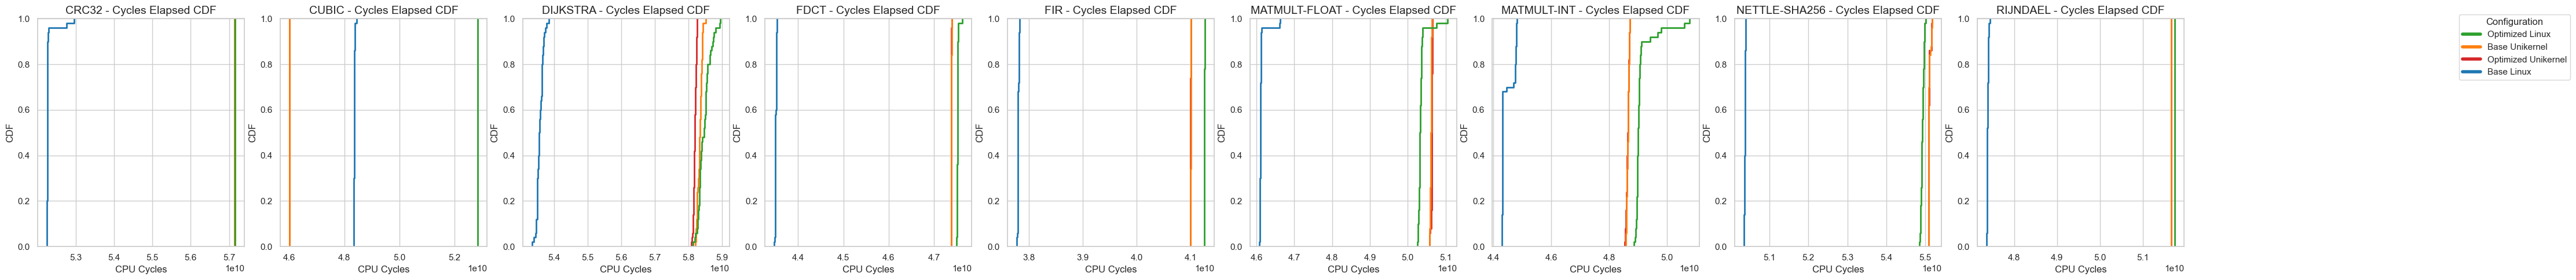


Mean CPU Cycles by Benchmark and Configuration:


source,Optimized Linux,Base Unikernel,Optimized Unikernel,Base Linux
benchmark,,,,
crc32,5.7158145e+10,5.7142044e+10,5.7139758e+10,5.2281217e+10
cubic,5.2847969e+10,4.6008282e+10,4.6006498e+10,4.8363756e+10
dijkstra,5.846967e+10,5.8337868e+10,5.8190453e+10,5.3567518e+10
fdct,4.7519568e+10,4.7385911e+10,4.7383759e+10,4.3507558e+10
fir,4.1254598e+10,4.1003389e+10,4.1000323e+10,3.780811e+10
matmult-float,5.0348614e+10,5.0610785e+10,5.0636322e+10,4.612767e+10
matmult-int,4.910582e+10,4.864679e+10,4.8642767e+10,4.4449264e+10
nettle-sha256,5.492316e+10,5.5102523e+10,5.5100813e+10,5.0369198e+10
rijndael,5.1732542e+10,5.1659392e+10,5.1657293e+10,4.7385265e+10



Standard Deviation of CPU Cycles by Benchmark and Configuration:


source,Optimized Linux,Base Unikernel,Optimized Unikernel,Base Linux
benchmark,,,,
crc32,936795,292047.44,445921.5,1.1980942e+08
cubic,1330614.4,837639.43,749483.35,19137842
dijkstra,1.8332932e+08,67446127,41869146,95605215
fdct,17199435,1390224.5,1277707.6,13171946
fir,4516193.7,3129615.5,3293244.4,12551326
matmult-float,1.2269845e+08,15885557,16639557,1.0325535e+08
matmult-int,3.6742136e+08,39098693,46337354,2.1520225e+08
nettle-sha256,36874187,24954812,24796955,12472318
rijndael,483628.07,298268.46,224337.96,13812660


In [39]:
# Compare CPU cycles across configurations
# Create CDF plots for CPU cycles

# Filter out Base Linux
plot_hue_order = ['Optimized Linux', 'Base Unikernel', 'Optimized Unikernel', 'Base Linux']
plot_palette = ['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4']

for group_idx, benchmarks_to_plot in enumerate(benchmark_groups):
    n_plots = len(benchmarks_to_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    
    # Handle single plot case
    if n_plots == 1:
        axes = [axes]
    
    for idx, benchmark in enumerate(benchmarks_to_plot):
        ax = axes[idx]
        benchmark_data = all_data[(all_data['benchmark'] == benchmark)]
        
        # Use seaborn's ecdfplot for CDF - using cpu_cycles column
        sns.ecdfplot(
            data=benchmark_data, 
            x='cpu_cycles', 
            hue='source',
            hue_order=plot_hue_order,
            palette=plot_palette,
            linewidth=2,
            ax=ax
        )
        
        ax.set_xlabel('CPU Cycles', fontsize=12)
        ax.set_ylabel('CDF', fontsize=12)
        ax.set_title(f'{benchmark.upper()} - Cycles Elapsed CDF', fontsize=14)
        
        # Get legend and remove it from individual plots
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    # Create custom legend with proper labels
    from matplotlib.lines import Line2D
    custom_handles = [Line2D([0], [0], color=c, linewidth=4) for c in plot_palette]
    fig.legend(custom_handles, plot_hue_order, title='Configuration', loc='upper right', bbox_to_anchor=(0.99, 0.95))

    plt.tight_layout()
    plt.subplots_adjust(right=0.84)  # Make room for legend
    plt.show()

# Create summary table for CPU cycles
print("\nMean CPU Cycles by Benchmark and Configuration:")
print("=" * 80)
cycles_mean = all_data.groupby(['benchmark', 'source'])['cpu_cycles'].mean().unstack()
cycles_mean = cycles_mean[plot_hue_order]  # Reorder columns
display(cycles_mean)

print("\nStandard Deviation of CPU Cycles by Benchmark and Configuration:")
print("=" * 80)
cycles_std = all_data.groupby(['benchmark', 'source'])['cpu_cycles'].std().unstack()
cycles_std = cycles_std[plot_hue_order]  # Reorder columns
display(cycles_std)

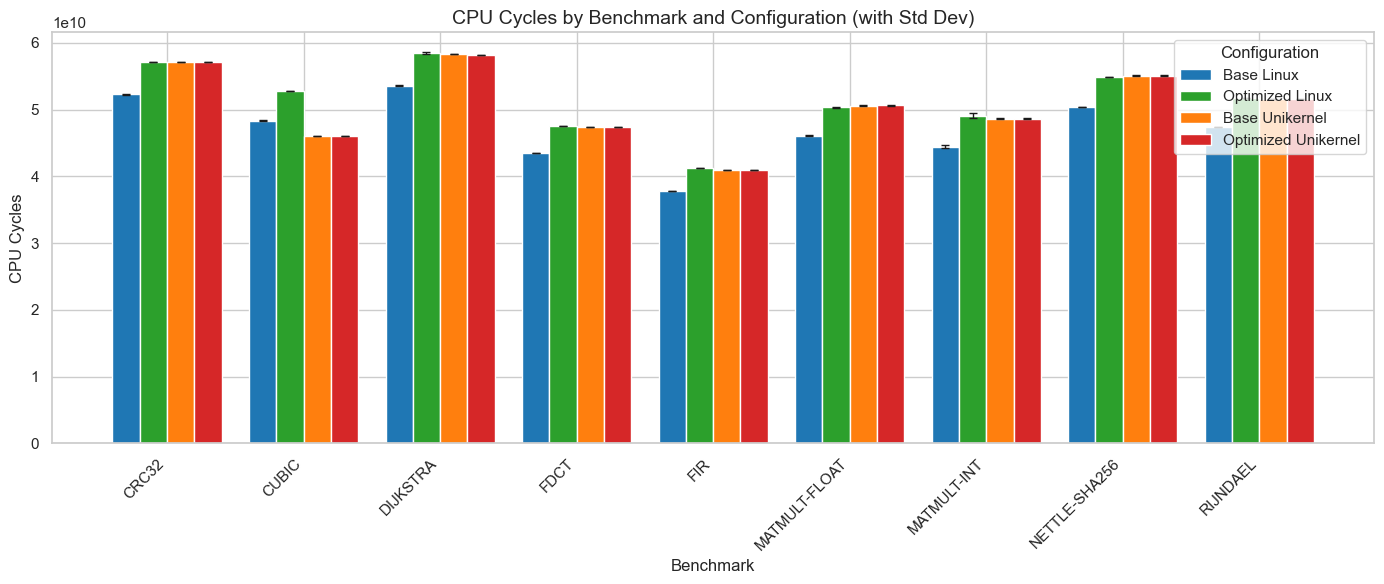

In [40]:
# Barplot with error bars showing CPU cycles difference between configurations
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate mean and std for each benchmark and configuration
cycles_stats = all_data.groupby(['benchmark', 'source'])['cpu_cycles'].agg(['mean', 'std']).reset_index()

# Set up bar positions
x = np.arange(len(all_benchmarks))
width = 0.2  # Width of each bar
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

# Plot bars for each configuration
for i, (source, color) in enumerate(zip(hue_order, palette)):
    source_data = cycles_stats[cycles_stats['source'] == source]
    # Ensure data is in the same order as all_benchmarks
    means = [source_data[source_data['benchmark'] == b]['mean'].values[0] for b in all_benchmarks]
    stds = [source_data[source_data['benchmark'] == b]['std'].values[0] for b in all_benchmarks]
    
    ax.bar(x + offsets[i], means, width, label=source, color=color, 
           yerr=stds, capsize=3, error_kw={'linewidth': 1})

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('CPU Cycles', fontsize=12)
ax.set_title('CPU Cycles by Benchmark and Configuration (with Std Dev)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in all_benchmarks], rotation=45, ha='right')
ax.legend(title='Configuration', loc='upper right')
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

In [41]:
# Calculate total cooldown time needed for each configuration
print("Total Cooldown Time by Configuration:")
print("=" * 80)

total_cooldown_data = []
for source in hue_order:
    source_data = all_data[all_data['source'] == source]
    total_ms = source_data['cooldown_ms'].sum()
    total_s = total_ms / 1000
    total_min = total_s / 60
    total_cooldown_data.append({
        'Configuration': source,
        'Total Cooldown (ms)': total_ms,
        'Total Cooldown (s)': total_s,
        'Total Cooldown (min)': total_min
    })

total_cooldown_df = pd.DataFrame(total_cooldown_data)
total_cooldown_df = total_cooldown_df.set_index('Configuration')
display(total_cooldown_df)

# Also show total cooldown per benchmark per configuration
print("\nTotal Cooldown Time (s) by Benchmark and Configuration:")
print("=" * 80)
cooldown_sum = all_data.groupby(['benchmark', 'source'])['cooldown_ms'].sum().unstack() / 1000  # Convert to seconds
cooldown_sum = cooldown_sum[hue_order]  # Reorder columns
display(cooldown_sum)

Total Cooldown Time by Configuration:


,Total Cooldown (ms),Total Cooldown (s),Total Cooldown (min)
Configuration,,,
Base Linux,36287.007,36.287007,0.60478345
Optimized Linux,13939.979,13.939979,0.23233298
Base Unikernel,8110,8.11,0.13516667
Optimized Unikernel,7450,7.45,0.12416667



Total Cooldown Time (s) by Benchmark and Configuration:


source,Base Linux,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,,
crc32,2.501673,0.422264,0,0
cubic,2.82788,0.717419,0.07,0.19
dijkstra,4.845508,2.173312,1.42,1.33
fdct,4.267319,1.66068,1.08,0.96
fir,4.186373,1.40589,1.06,0.77
matmult-float,4.470494,1.970058,1.24,0.95
matmult-int,4.59173,1.958487,1.15,1.05
nettle-sha256,4.419777,2.092111,1.15,1.17
rijndael,4.176253,1.539758,0.94,1.03


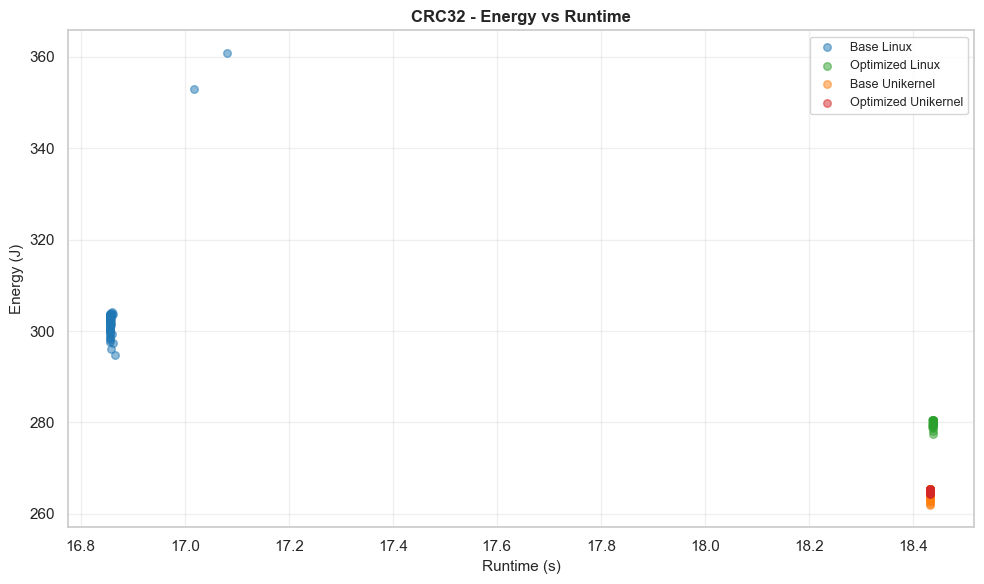

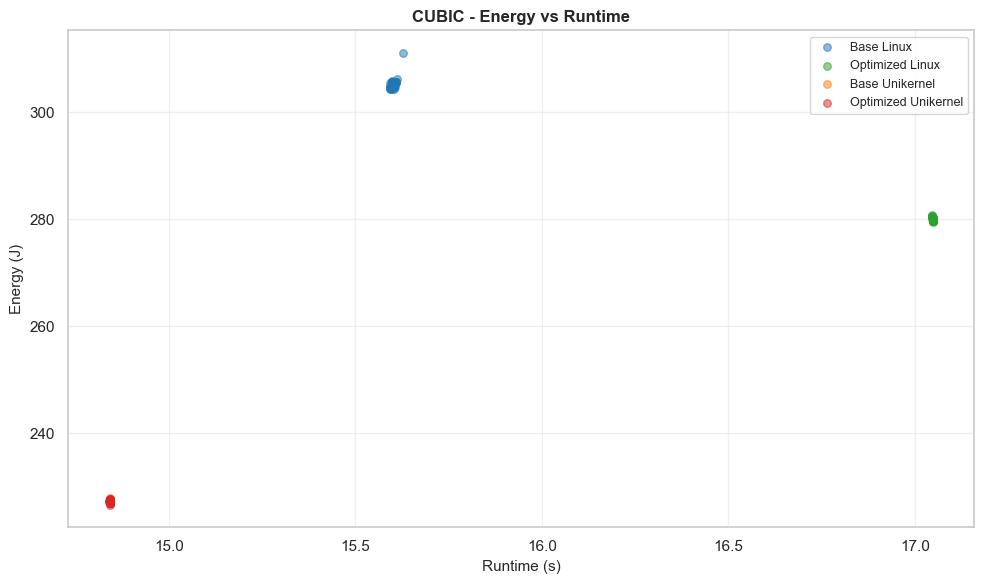

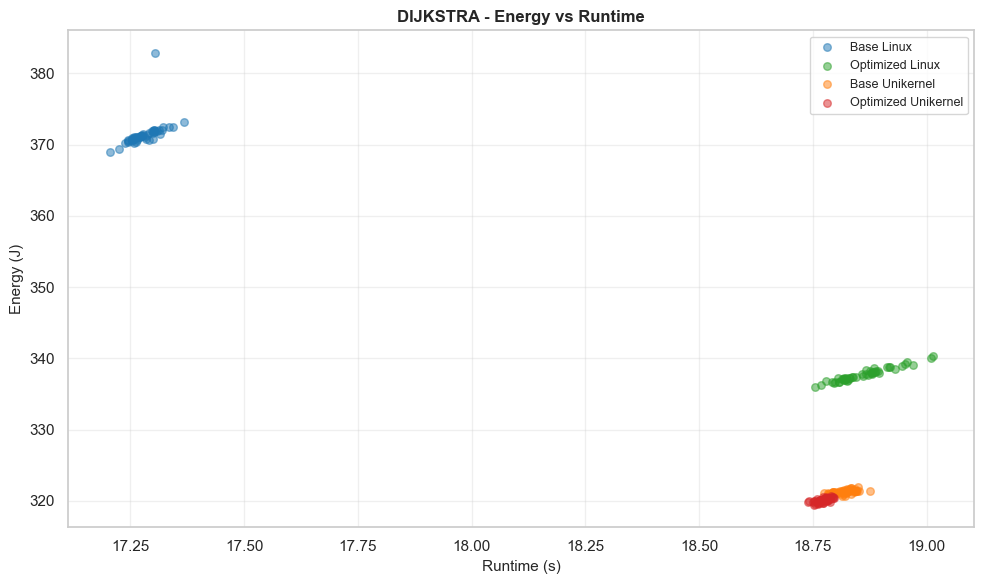

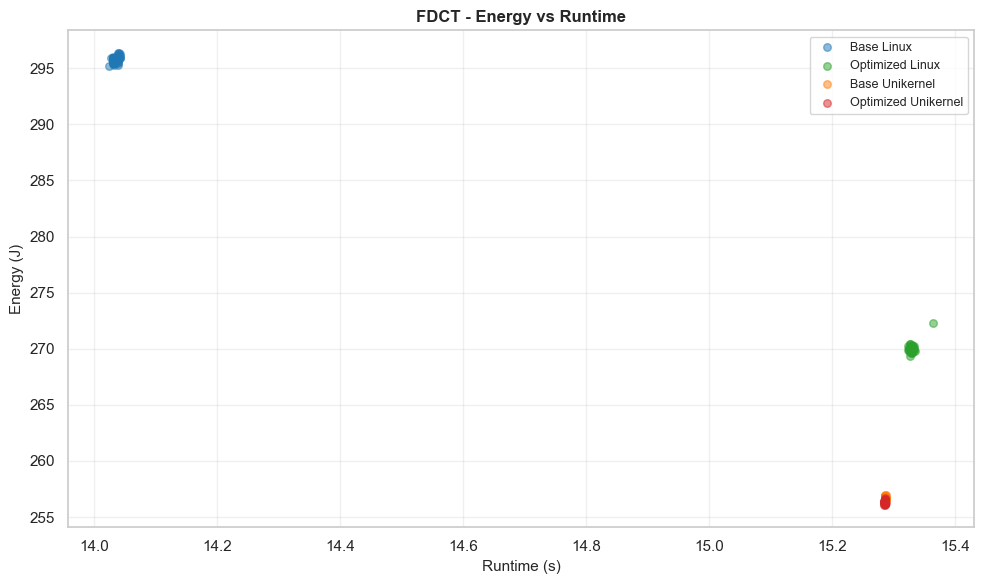

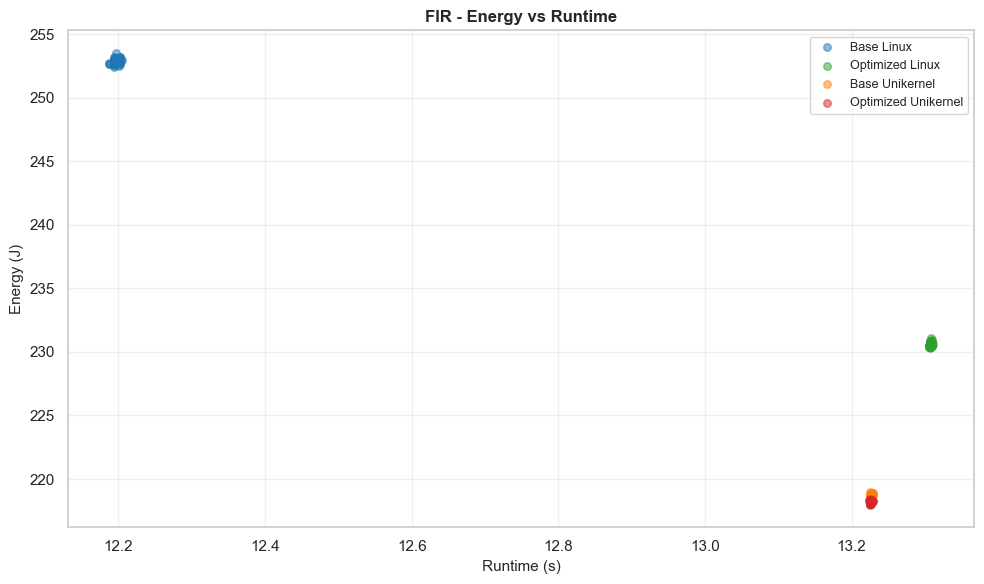

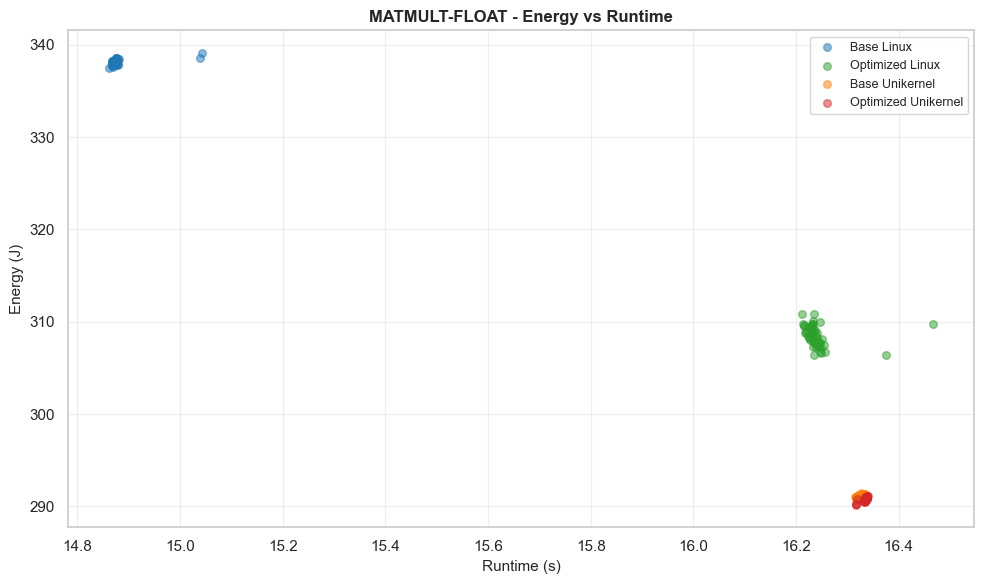

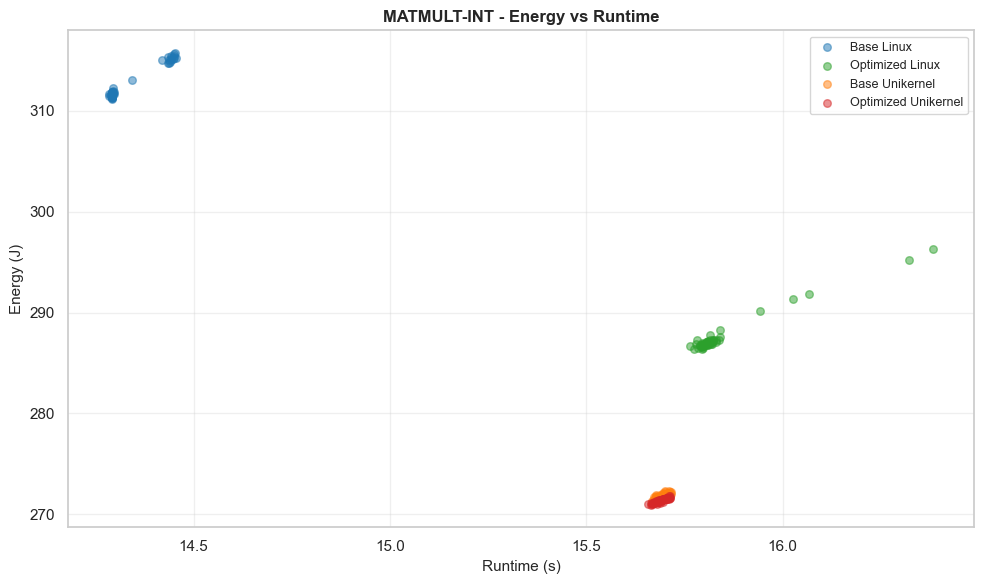

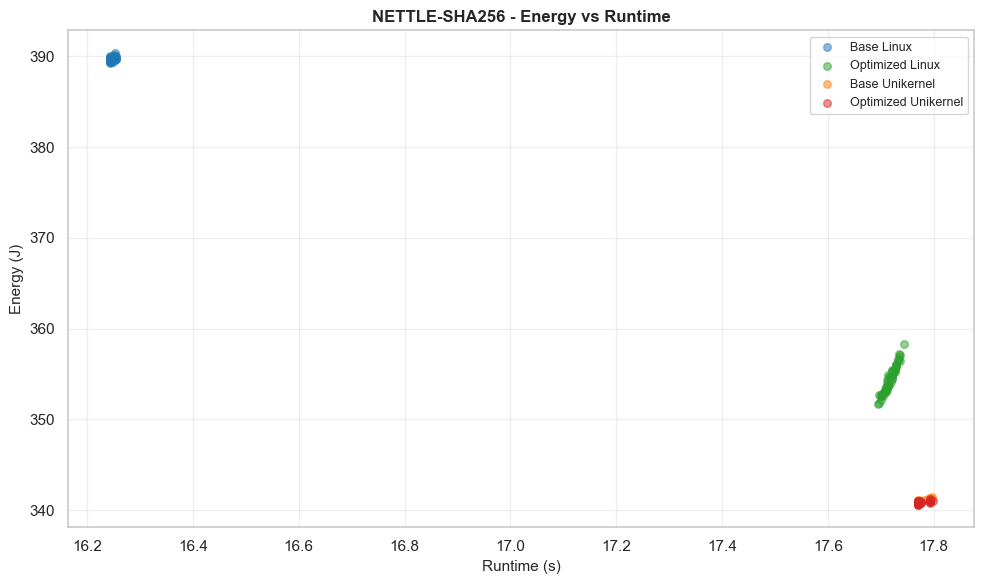

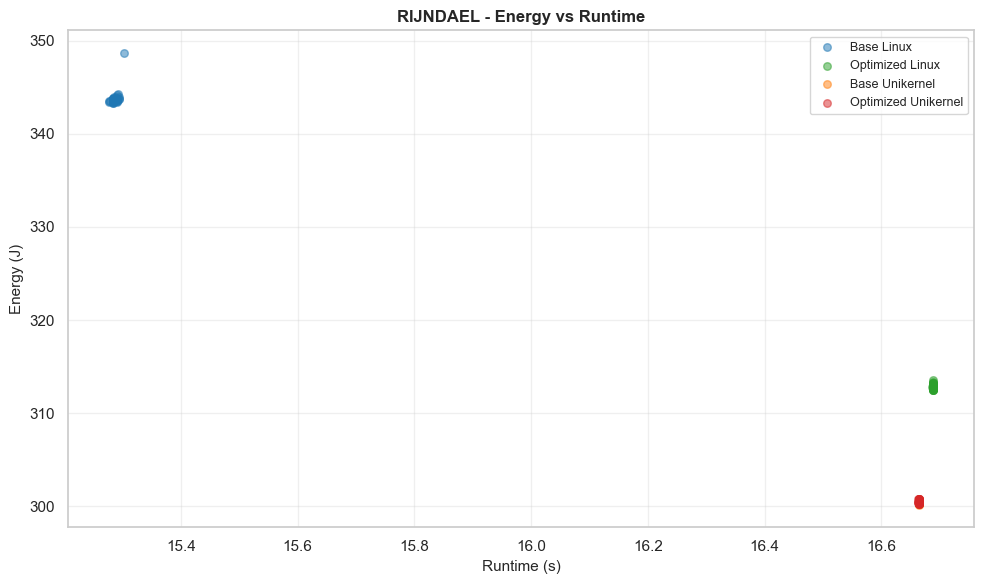


CORRELATION ANALYSIS: Energy vs CPU Cycles (CPU @ 3.1 GHz)

High correlation (r > 0.9) → Variation mainly from runtime fluctuations
Low correlation (r < 0.7) → Variation from power draw fluctuations


CRC32:
----------------------------------------------------------------------------------------------------
  Base Linux                | r=0.9729 (p=3.42e-32) | Runtime: 16.864909±0.038648 s | E/cycle: 5.808±0.200 nJ (CV=3.44%) | ✓ Runtime variation
  Optimized Linux           | r=-0.0140 (p=9.23e-01) | Runtime: 18.438111±0.000302 s | E/cycle: 4.899±0.010 nJ (CV=0.21%) | ⚠ Power fluctuation
  Base Unikernel            | r=-0.1835 (p=2.02e-01) | Runtime: 18.432917±0.000094 s | E/cycle: 4.630±0.016 nJ (CV=0.35%) | ⚠ Power fluctuation
  Optimized Unikernel       | r=-0.0887 (p=5.40e-01) | Runtime: 18.432180±0.000144 s | E/cycle: 4.638±0.004 nJ (CV=0.09%) | ⚠ Power fluctuation

CUBIC:
----------------------------------------------------------------------------------------------------
  Base

In [42]:
# Analysis: Energy vs CPU Cycles correlation to identify variation source
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# CPU frequency
CPU_FREQ_GHZ = 3.10

# Exclude crc32 for consistency
filtered_benchmarks = [b for b in all_benchmarks if b != '']

# Create individual plots for each benchmark
for benchmark in filtered_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    
    # Energy vs Runtime scatter plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    for source, color in zip(hue_order, palette):
        source_data = benchmark_data[benchmark_data['source'] == source]
        if not source_data.empty:
            # Convert cycles to seconds
            runtime_s = source_data['cpu_cycles'] / (CPU_FREQ_GHZ * 1e9)
            ax.scatter(runtime_s, source_data['total_joules'], 
                       alpha=0.5, s=30, color=color, label=source)
    
    ax.set_xlabel('Runtime (s)', fontsize=11)
    ax.set_ylabel('Energy (J)', fontsize=11)
    ax.set_title(f'{benchmark.upper()} - Energy vs Runtime', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'energy_vs_runtime_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Print correlation statistics
print("\n" + "="*100)
print(f"CORRELATION ANALYSIS: Energy vs CPU Cycles (CPU @ {CPU_FREQ_GHZ} GHz)")
print("="*100)
print("\nHigh correlation (r > 0.9) → Variation mainly from runtime fluctuations")
print("Low correlation (r < 0.7) → Variation from power draw fluctuations\n")

for benchmark in filtered_benchmarks:
    print(f"\n{benchmark.upper()}:")
    print("-" * 100)
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]
        if len(source_data) > 2:
            corr, p_value = stats.pearsonr(source_data['cpu_cycles'], source_data['total_joules'])
            
            # Calculate energy per cycle stats
            energy_per_cycle = source_data['total_joules'] / source_data['cpu_cycles'] * 1e9
            epc_mean = energy_per_cycle.mean()
            epc_std = energy_per_cycle.std()
            epc_cv = (epc_std / epc_mean * 100)
            
            # Calculate runtime in seconds: cycles / (freq_GHz * 10^9)
            runtime_s = source_data['cpu_cycles'] / (CPU_FREQ_GHZ * 1e9)
            runtime_mean_s = runtime_s.mean()
            runtime_std_s = runtime_s.std()
            
            interpretation = "✓ Runtime variation" if corr > 0.9 else "⚠ Power fluctuation" if corr < 0.7 else "~ Mixed"
            
            print(f"  {source:25s} | r={corr:.4f} (p={p_value:.2e}) | Runtime: {runtime_mean_s:.6f}±{runtime_std_s:.6f} s | E/cycle: {epc_mean:.3f}±{epc_std:.3f} nJ (CV={epc_cv:.2f}%) | {interpretation}")

print("\n" + "="*100)

# Variation Source Analysis: Runtime vs Power Fluctuations

If energy variation comes from **runtime fluctuations**, energy and CPU cycles should be highly correlated (linear relationship).

If energy variation comes from **power draw fluctuations**, energy/cycle ratio will vary even when cycles are similar.

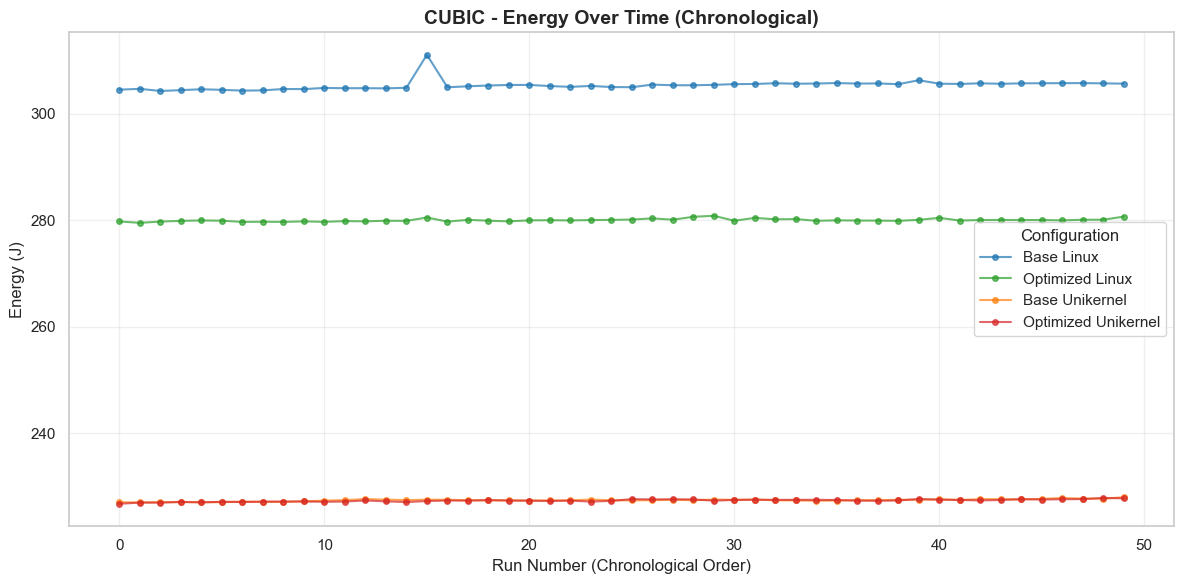

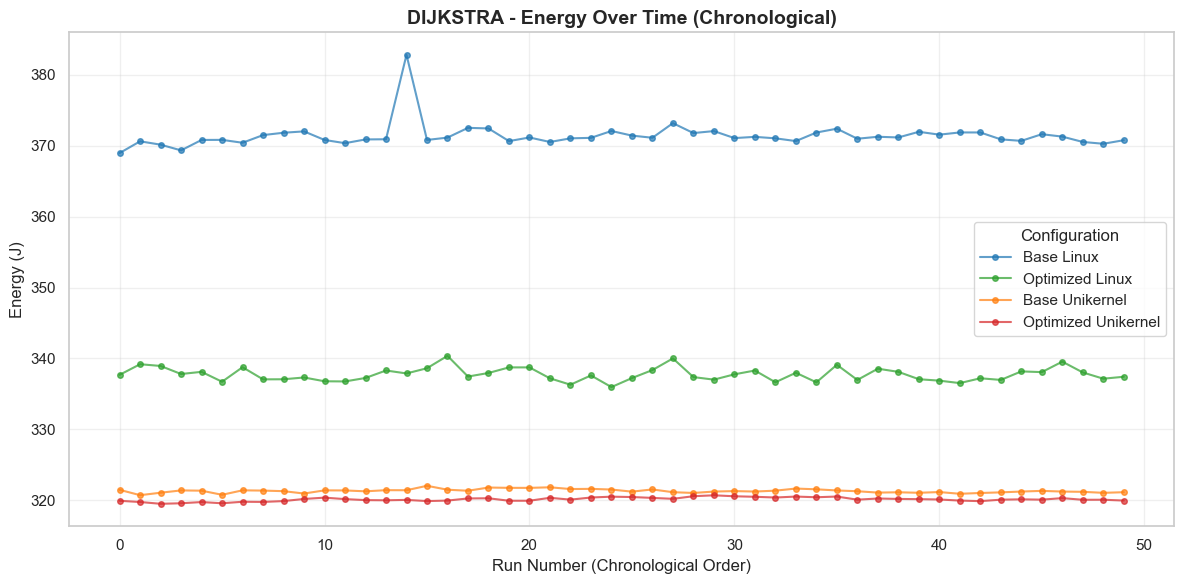

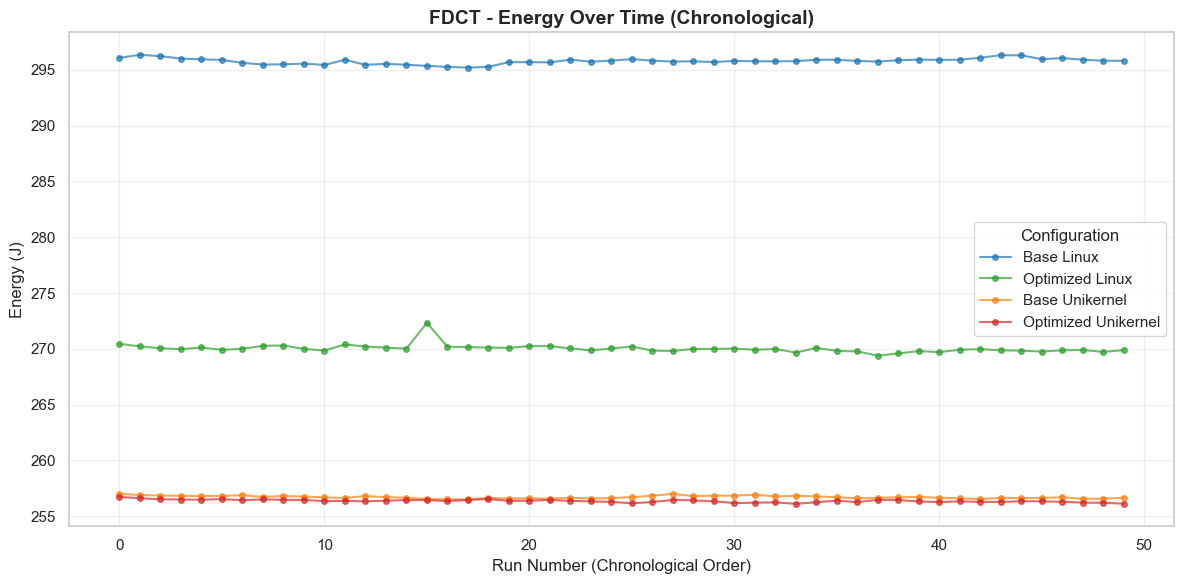

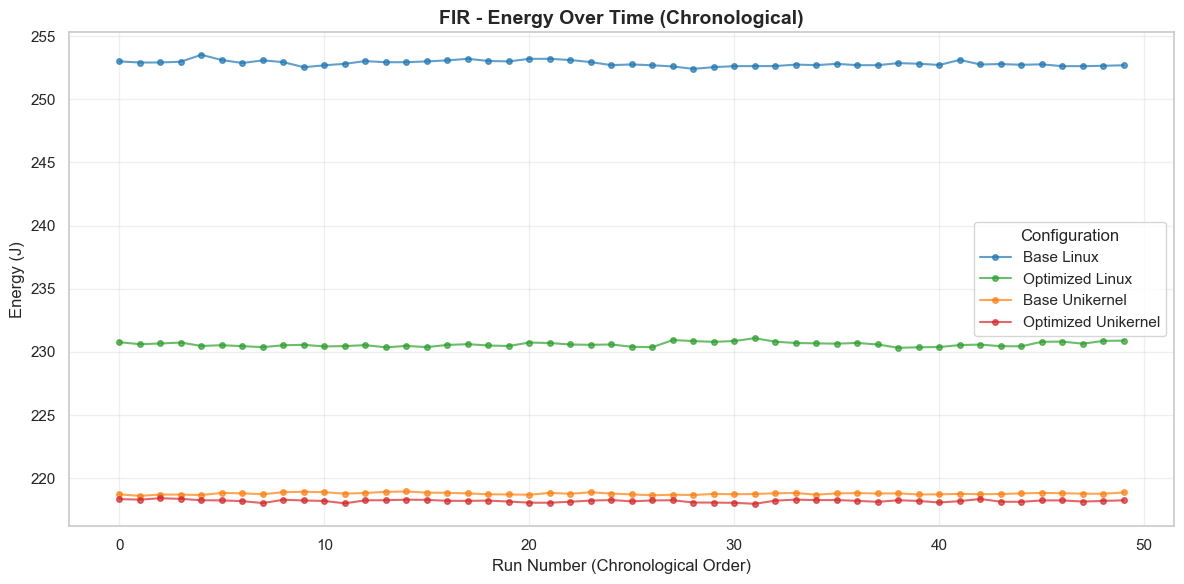

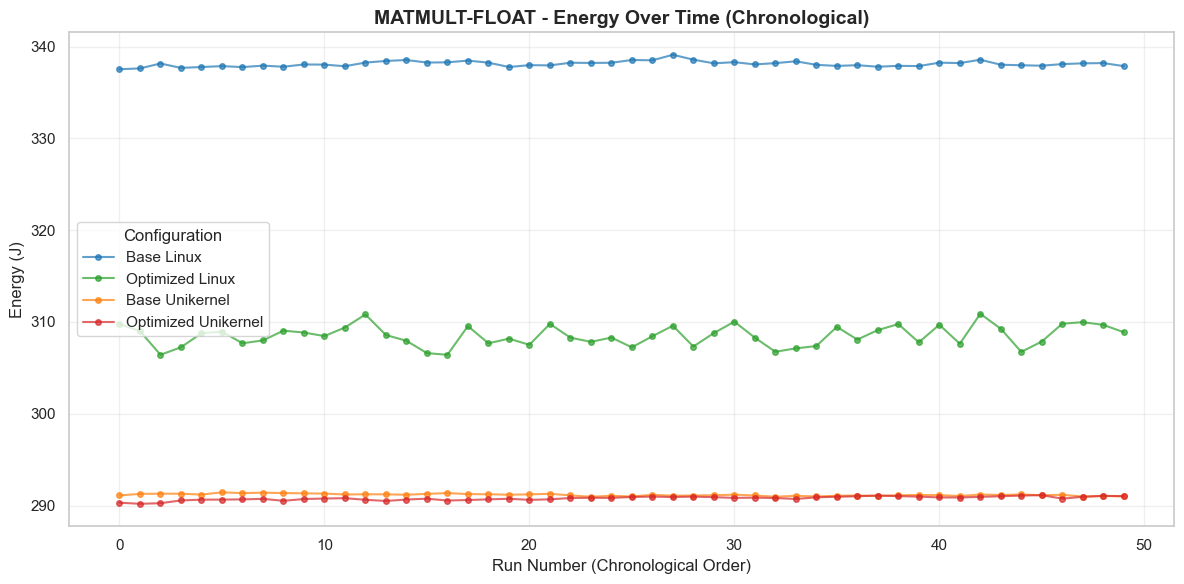

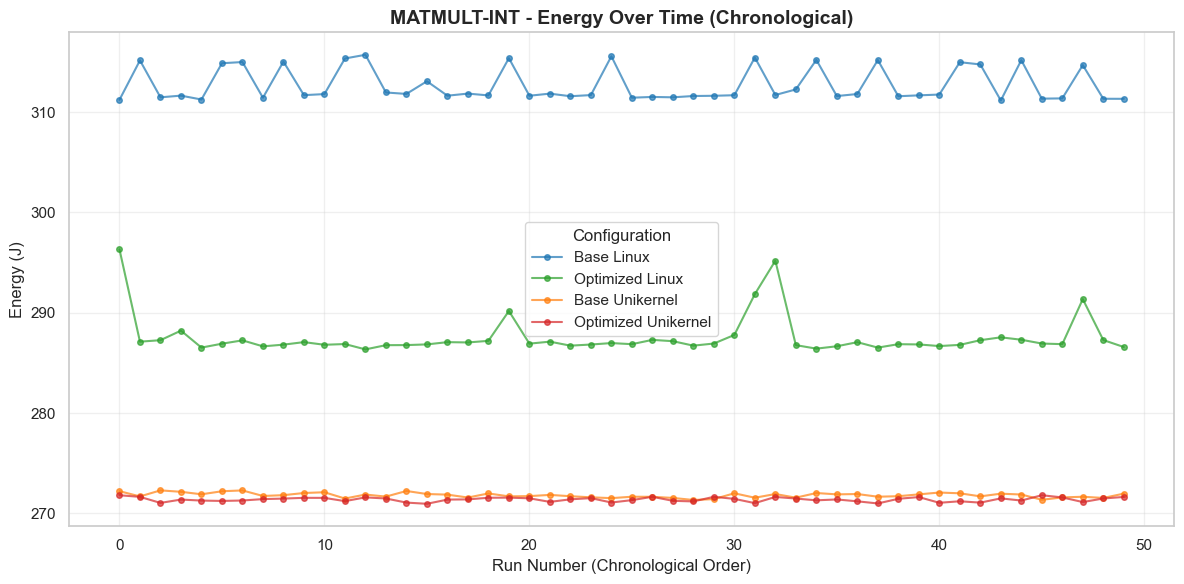

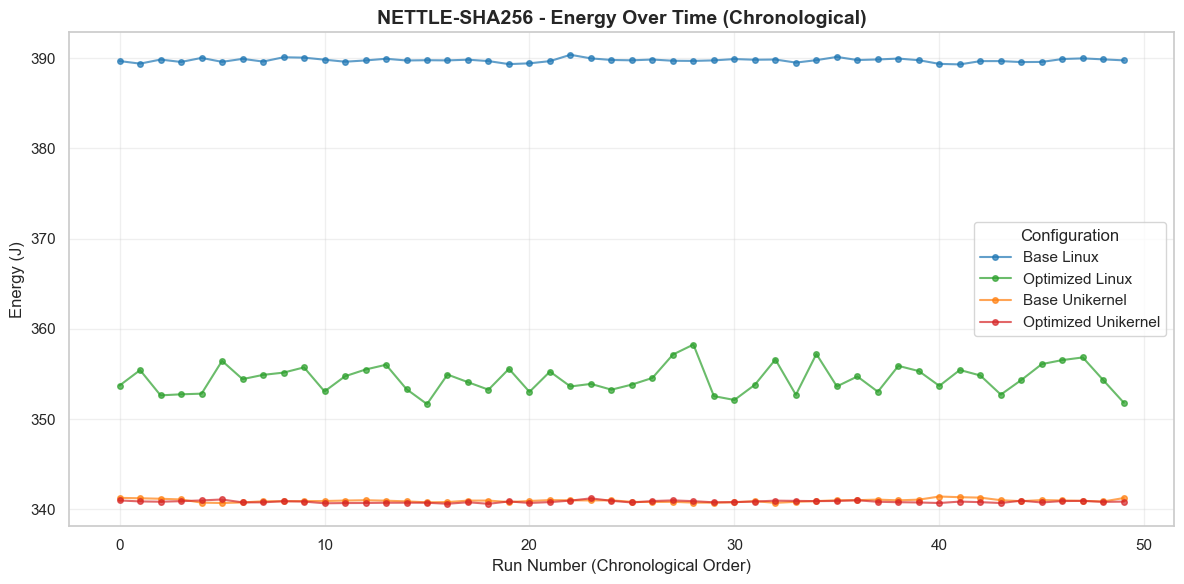

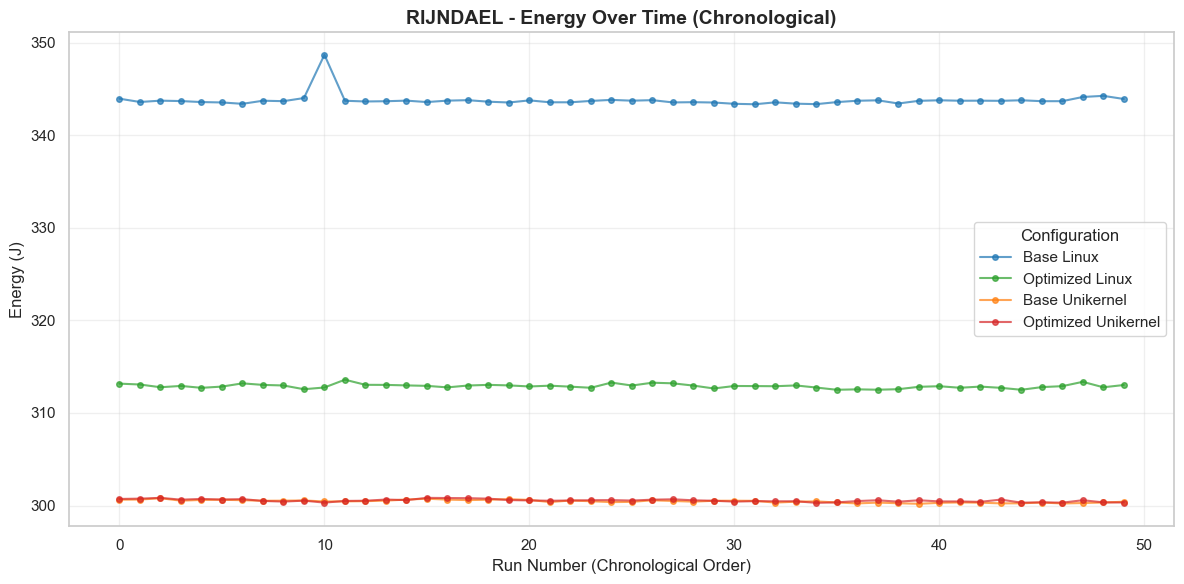

In [43]:
# Chronological line plot of energy consumption by configuration
import matplotlib.pyplot as plt
import seaborn as sns

# Filter benchmarks (exclude crc32 if desired)
filtered_benchmarks = [b for b in all_benchmarks if b != 'crc32']

# Create line plots for each benchmark
for benchmark in filtered_benchmarks:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    benchmark_data = all_data[all_data['benchmark'] == benchmark].copy()
    
    # Plot each configuration
    for source, color in zip(hue_order, palette):
        source_data = benchmark_data[benchmark_data['source'] == source].copy()
        if not source_data.empty:
            # Reset index to get chronological order (0, 1, 2, ...)
            source_data = source_data.reset_index(drop=True)
            source_data['run_number'] = range(len(source_data))
            
            ax.plot(source_data['run_number'], source_data['total_joules'], 
                   color=color, marker='o', markersize=4, linewidth=1.5, 
                   alpha=0.7, label=source)
    
    ax.set_xlabel('Run Number (Chronological Order)', fontsize=12)
    ax.set_ylabel('Energy (J)', fontsize=12)
    ax.set_title(f'{benchmark.upper()} - Energy Over Time (Chronological)', fontsize=14, fontweight='bold')
    ax.legend(title='Configuration', loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'energy_timeline_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()